Correlation matrix:
                 btc_return_pct  fng_value  is_holiday  is_weekend
btc_return_pct        1.000000   0.028936   -0.007830   -0.000808
fng_value             0.028936   1.000000    0.072579   -0.034252
is_holiday           -0.007830   0.072579    1.000000   -0.142121
is_weekend           -0.000808  -0.034252   -0.142121    1.000000


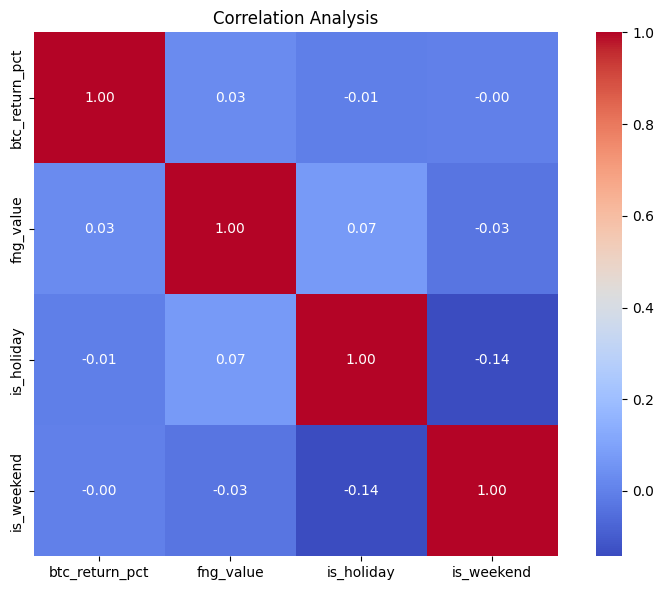

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Load gold dataset
# -----------------------------
gold_path = "data/gold/btc_fng_with_holidays_api.csv"
merged = pd.read_csv(gold_path, parse_dates=["date"])

# Ensure necessary columns exist
if "btc_return_pct" not in merged.columns:
    merged["btc_return_pct"] = merged["btc_close"].pct_change()
merged = merged.dropna(subset=["btc_return_pct", "fng_value"])

# Add additional features if needed
if "is_holiday" not in merged.columns:
    merged["is_holiday"] = merged["date"].dt.dayofweek.isin([5,6])
merged["is_weekend"] = merged["date"].dt.dayofweek >= 5

# -----------------------------
# 2) Select numeric columns for correlation
# -----------------------------
corr_columns = ["btc_return_pct", "fng_value", "is_holiday", "is_weekend"]
corr_data = merged[corr_columns].copy()

# Convert boolean columns to int for correlation
corr_data["is_holiday"] = corr_data["is_holiday"].astype(int)
corr_data["is_weekend"] = corr_data["is_weekend"].astype(int)

# -----------------------------
# 3) Compute correlation matrix
# -----------------------------
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

# -----------------------------
# 4) Plot heatmap
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Analysis")
plt.tight_layout()
plt.show()